In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)

c:\Users\AB\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\AB\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
df = pd.read_excel(r"C:\Users\AB\Downloads\archive (31)\finalDataset0.2.xlsx")

In [4]:
import os

os.listdir()

['bin',
 'Code.exe',
 'Code.VisualElementsManifest.xml',
 'df53daabb1',
 'unins000.dat',
 'unins000.exe',
 'unins000.msg']

In [5]:
print(df.head())

   teaching                                         teaching.1  coursecontent  \
0         0  teacher are punctual but they should also give...            0.0   
1         1                                              Good            -1.0   
2         1  Excellent lectures are delivered by teachers a...            1.0   
3         1                                               Good           -1.0   
4         1  teachers give us all the information required ...            1.0   

                                     coursecontent.1  examination  \
0                     content of courses are average          1.0   
1                                           Not good          1.0   
2  All courses material provide very good knowled...          1.0   
3  Content of course is perfectly in line with th...         -1.0   
4           content of courses improves my knowledge          1.0   

                                         Examination  labwork  \
0                        examinat

In [6]:
print(df.isnull().sum())

teaching               0
teaching.1             0
coursecontent          1
coursecontent.1        0
examination            1
Examination            0
labwork                0
labwork.1              0
library_facilities     3
 library_facilities    0
extracurricular        0
extracurricular.1      0
dtype: int64


In [7]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   teaching             185 non-null    int64  
 1   teaching.1           185 non-null    str    
 2   coursecontent        184 non-null    float64
 3   coursecontent.1      185 non-null    str    
 4   examination          184 non-null    float64
 5   Examination          185 non-null    str    
 6   labwork              185 non-null    int64  
 7   labwork.1            185 non-null    str    
 8   library_facilities   182 non-null    float64
 9    library_facilities  185 non-null    str    
 10  extracurricular      185 non-null    int64  
 11  extracurricular.1    185 non-null    str    
dtypes: float64(3), int64(3), str(6)
memory usage: 60.8 KB
None


In [8]:
print(df.columns.tolist())

['teaching', 'teaching.1', 'coursecontent', 'coursecontent.1', 'examination', 'Examination', 'labwork', 'labwork.1', 'library_facilities', ' library_facilities', 'extracurricular', 'extracurricular.1']


In [9]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()

    words = [
        word for word in words
        if word not in stop_words
    ]

    return ' '.join(words)

In [10]:
text_columns = [
    'teaching.1',
    'coursecontent.1',
    'Examination',
    'labwork.1',
    ' library_facilities',
    'extracurricular.1',
]

df['feedback_text'] = df[text_columns].astype(str).agg(' '.join, axis=1)
df['Clean_Feedback'] = df['feedback_text'].apply(clean_text)

In [11]:
sentiment_cols = [
    'teaching',
    'coursecontent',
    'examination',
    'labwork',
    'library_facilities',
    'extracurricular',
]

available_sentiment_cols = [col for col in sentiment_cols if col in df.columns]

if not available_sentiment_cols:
    raise KeyError('No sentiment score columns were found in the dataframe.')

df['Sentiment_Score'] = df[available_sentiment_cols].mean(axis=1)
df['Sentiment_Label'] = df['Sentiment_Score'].apply(
    lambda score: 'Positive' if score > 0 else 'Negative' if score < 0 else 'Neutral'
)

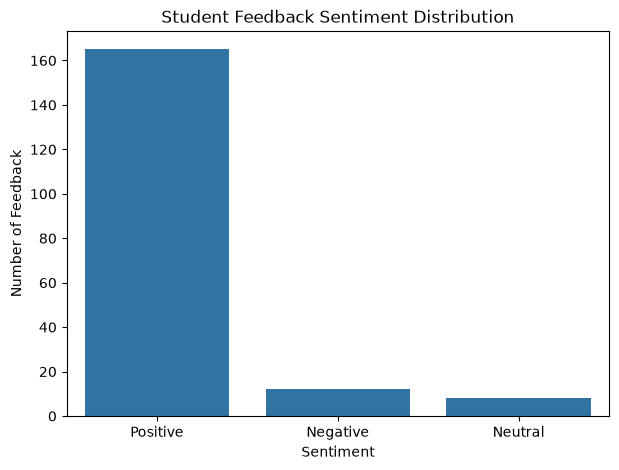

In [12]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='Sentiment_Label'
)

plt.title("Student Feedback Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Feedback")
plt.show()

In [13]:
X = df['Clean_Feedback']
y = df['Sentiment_Label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [15]:
model_lr = LogisticRegression(
    max_iter=1000
)

model_lr.fit(
    X_train_tfidf,
    y_train
)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [16]:
y_pred_lr = model_lr.predict(X_test_tfidf)

In [17]:
accuracy_lr = accuracy_score(
    y_test,
    y_pred_lr
)

print("Logistic Regression Accuracy:",
      accuracy_lr)

Logistic Regression Accuracy: 0.8918918918918919


In [18]:
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         2
     Neutral       0.00      0.00      0.00         2
    Positive       0.89      1.00      0.94        33

    accuracy                           0.89        37
   macro avg       0.30      0.33      0.31        37
weighted avg       0.80      0.89      0.84        37



c:\Users\AB\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\AB\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\AB\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [19]:
model_nb = MultinomialNB()

model_nb.fit(
    X_train_tfidf,
    y_train
)

y_pred_nb = model_nb.predict(
    X_test_tfidf
)

print(
    "Naive Bayes Accuracy:",
    accuracy_score(y_test, y_pred_nb)
)

Naive Bayes Accuracy: 0.8918918918918919


In [20]:
model_svm = LinearSVC()

model_svm.fit(
    X_train_tfidf,
    y_train
)

y_pred_svm = model_svm.predict(
    X_test_tfidf
)

print(
    "SVM Accuracy:",
    accuracy_score(y_test, y_pred_svm)
)

SVM Accuracy: 0.8918918918918919


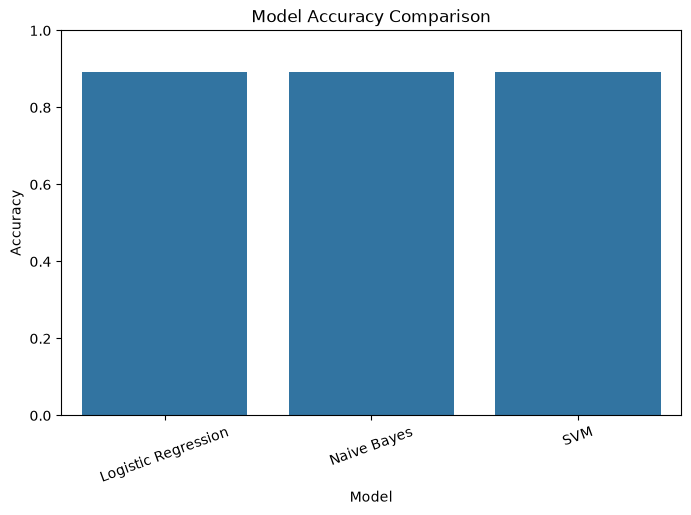

In [23]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'SVM'],
    'Accuracy': [
        accuracy_lr,
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm)
    ]
})

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='Accuracy'
)

plt.ylim(0,1)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)
plt.show()

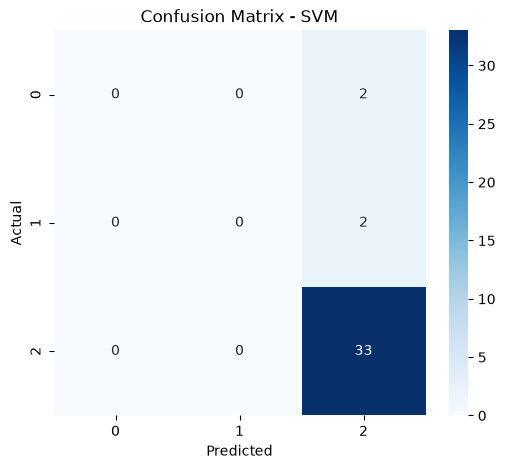

In [24]:
cm = confusion_matrix(
    y_test,
    y_pred_svm
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")

plt.show()

In [25]:
negative_feedback = df[
    df['Sentiment_Label'] == 'Negative'
]

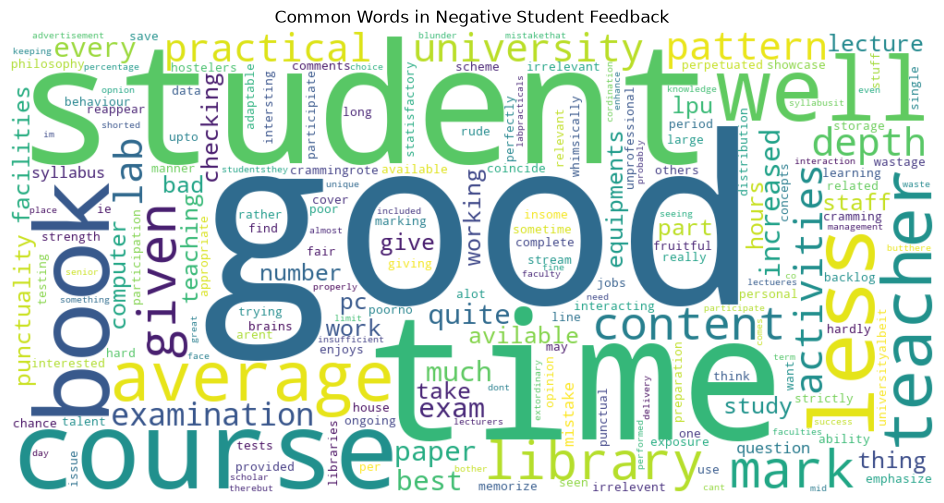

In [27]:
negative_text = ' '.join(
    negative_feedback['Clean_Feedback'].dropna().astype(str)
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(12,6))

plt.imshow(
    wordcloud,
    interpolation='bilinear'
)

plt.axis('off')

plt.title(
    "Common Words in Negative Student Feedback"
)

plt.show()

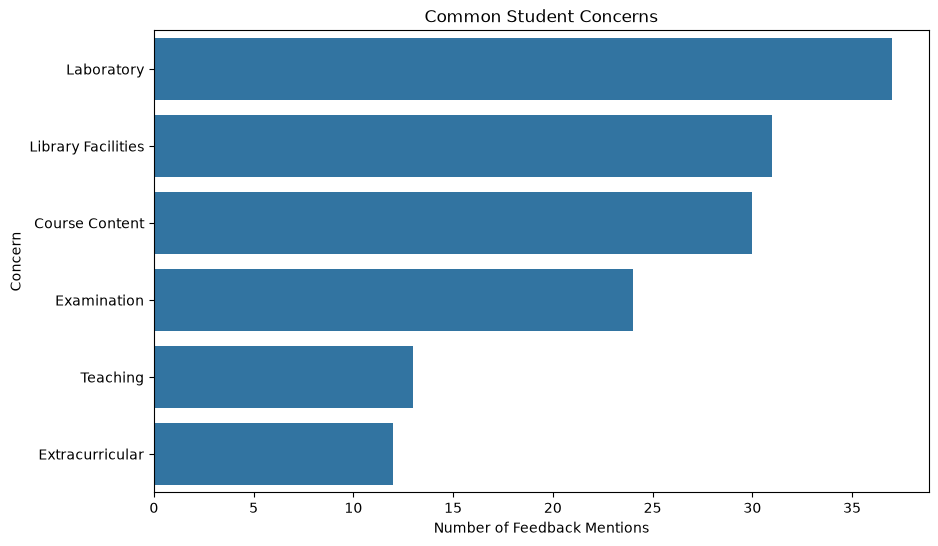

In [33]:
concern_labels = {
    'teaching': 'Teaching',
    'coursecontent': 'Course Content',
    'examination': 'Examination',
    'labwork': 'Laboratory',
    'library_facilities': 'Library Facilities',
    'extracurricular': 'Extracurricular'
}

concern_df = pd.DataFrame({
    'Concern': [concern_labels[col] for col in available_sentiment_cols],
    'Count': [int((df[col] < 0).sum()) for col in available_sentiment_cols]
})

plt.figure(figsize=(10,6))

sns.barplot(
    data=concern_df.sort_values(
        'Count',
        ascending=False
    ),
    x='Count',
    y='Concern'
)

plt.title("Common Student Concerns")
plt.xlabel("Number of Feedback Mentions")
plt.ylabel("Concern")

plt.show()

In [30]:
def predict_feedback(text):

    cleaned = clean_text(text)

    vector = tfidf.transform([cleaned])

    prediction = model_svm.predict(vector)[0]

    return prediction

In [28]:
feature_names = tfidf.get_feature_names_out()

mean_scores = X_train_tfidf.mean(axis=0)

scores = np.asarray(
    mean_scores
).flatten()

word_scores = pd.DataFrame({
    'Word': feature_names,
    'Score': scores
})

word_scores = word_scores.sort_values(
    by='Score',
    ascending=False
)

print(word_scores.head(20))

                Word     Score
1201            good  0.197738
1263       good good  0.151318
929        excellent  0.045504
192          average  0.029464
1246  good excellent  0.027600
3239      university  0.022223
294            books  0.021727
939   excellent good  0.020877
2877        students  0.020782
544           course  0.019488
1856         library  0.018706
2212              ok  0.017229
1727             lab  0.015434
81              also  0.014976
1208    good average  0.014927
33        activities  0.014642
3068        teaching  0.014397
3039        teachers  0.013989
2110            much  0.013828
3417            work  0.013644


In [29]:
suggestions = {
    'Teaching':
        'Provide faculty training and use more interactive teaching methods.',

    'Course Content':
        'Update course materials and provide clearer study resources.',

    'Examination':
        'Improve question-paper clarity and provide sample question papers.',

    'Assignments':
        'Balance assignment workload and provide clearer instructions.',

    'Laboratory':
        'Increase practical sessions and improve laboratory resources.',

    'Infrastructure':
        'Improve classroom facilities, internet access and library resources.'
}
